In [67]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
%matplotlib inline

In [68]:
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService

# Load environment variables from .env
load_dotenv()

def get_ibm_service():
    token = os.getenv("IBM_QUANTUM_TOKEN")
    if not token:
        raise ValueError("IBM_QUANTUM_TOKEN not found in environment.")
    
    # Use 'ibm_quantum_platform' instead of 'ibm_quantum'
    return QiskitRuntimeService(channel="ibm_quantum_platform", token=token)

In [69]:
def run_on_real_hardware(circuit: QuantumCircuit):
    service = get_ibm_service()
    backend = service.least_busy(simulator=False, operational=True)
    print(f"Executing on: {backend.name}")
    
    # 1. Create a PassManager for the specific backend
    # optimization_level 1-3 (3 is highest optimization)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    
    # 2. Transpile the circuit to the backend's ISA
    isa_circuit = pm.run(circuit)
    
    sampler = Sampler(mode=backend)
    
    # 3. Submit the ISA-compliant circuit
    job = sampler.run([isa_circuit], shots=500)
    result = job.result()
    
    pub_result = result[0]
    # In hardware runs, bitstring keys are more reliable than getattr
    return pub_result.data.c.get_counts()

In [70]:
def create_superposition_circuit() -> QuantumCircuit:
    """
    Constructs a 1-qubit circuit implementing a Hadamard gate 
    to achieve the state: 1/sqrt(2) * (|0> + |1>).
    """
    # Initialize circuit with 1 qubit and 1 classical bit
    qc = QuantumCircuit(1, 1)
    
    # Apply Hadamard gate to put the qubit in superposition
    qc.h(0)
    
    # Measure the qubit into the classical bit
    qc.measure(0, 0)
    
    return qc

In [71]:
def run_simulation(circuit: QuantumCircuit, total_shots: int = 500):
    """
    Executes the circuit using the V2 Sampler primitive.
    Note: We wrap 'circuit' in a list [] to satisfy the PUB requirement.
    """
    sampler = Sampler()
    
    # The fix: wrap circuit in a list
    job = sampler.run([circuit], shots=total_shots) 
    result = job.result()
    
    # In V2, results are accessed via index for each PUB
    pub_result = result[0]
    
    # Get counts/probabilities from the classical register (usually 'c')
    counts = pub_result.data.c.get_counts()
    return counts

In [72]:
def create_entanglement_circuit() -> QuantumCircuit:
    """
    Constructs a 2-qubit circuit that creates a Bell state (|00> + |11>)/sqrt(2).
    """
    qc = QuantumCircuit(2, 2)
    
    # Step 1: Apply Hadamard to the first qubit to create superposition
    qc.h(0)
    
    # Step 2: Apply CNOT with control qubit 0 and target qubit 1 to entangle them
    qc.cx(0, 1)
    
    # Measure both qubits into their respective classical bits
    qc.measure([0, 1], [0, 1])
    
    return qc

qiskit_runtime_service._discover_account:WARNING:2026-03-13 18:56:15,411: Loading account with the given token. A saved account will not be used.


Circuit Diagram:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


qiskit_runtime_service.__init__:WARNING:2026-03-13 18:56:18,507: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-13 18:56:19,116: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-13 18:56:21,476: Using instance: open-instance, plan: open


Executing on: ibm_fez

Measurement results from real hardware: {'00': 237, '11': 237, '01': 12, '10': 14}


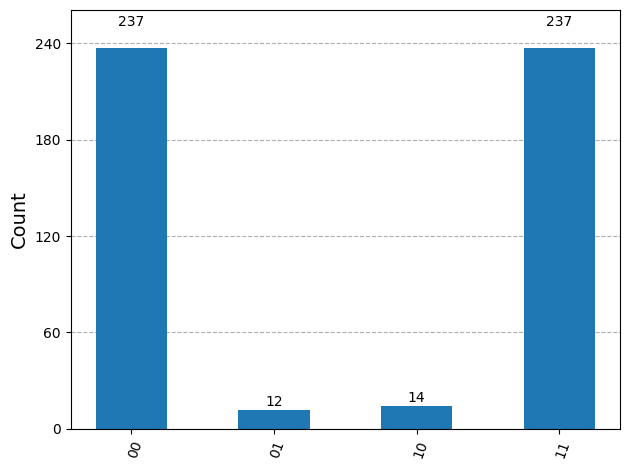

In [74]:
if __name__ == "__main__":
    circuit = create_entanglement_circuit()
    
    # Visualize the circuit
    print("Circuit Diagram:")
    print(circuit.draw(output='text'))
    
    # Run and plot results 
    results = run_on_real_hardware(circuit)
    print(f"\nMeasurement results from real hardware: {results}")
    plot_histogram(results)
    plt.show()